# SPICE-posed synthetic lunar satellite imagery

Demo: pose a synthetic pinhole camera using the **real LRO spacecraft trajectory** (NAIF SPICE kernels) at the timestamp of an actual LROC WAC EDR image, render a synthetic 256x256 image from real Lunaserv WMS DEM/imagery with NASA's Ames Stereo Pipeline `sat_sim`, and compare it against the real WAC data. See `../docs/plan.md` for the full phase-by-phase approach and `../docs/data-sources.md` for the researched specifics referenced below.

This notebook drives the installed `trntest` package (see `../src/trntest/`) rather than duplicating its logic -- each cell is close to a one-line call into the package.

In [1]:
import dataclasses
import json

import trntest
from trntest import plotting

session = trntest.Session()
session.config.output_dir.mkdir(parents=True, exist_ok=True)

## Phase 2: SPICE-derived camera pose

Pose a pinhole camera at framelet 0 of WAC EDR product `M1329714703CE`, using LRO's real position/orientation (from NAIF SPICE kernels, in the `MOON_ME` frame) at that instant.

In [2]:
camera = session.build_camera()
print(json.dumps(dataclasses.asdict(camera), indent=2, default=str))

{
  "et": 628347846.3816407,
  "center_frame_index": 475.5,
  "camera_center_moon_me_m": [
    -121454.93409817197,
    241847.0530020635,
    -1785989.760668606
  ],
  "r_cam_to_me": [
    [
      0.6004306113200643,
      -0.7956664734566607,
      0.07998714901066356
    ],
    [
      0.7964962113419072,
      0.586130975346279,
      -0.14847311223789816
    ],
    [
      0.07125213195267499,
      0.15285726268862787,
      0.9856763114407986
    ]
  ],
  "slant_range_km": 68.99158496182986,
  "off_nadir_deg": 1.1236683705106374,
  "focal_length_px": 215.57656937953163,
  "footprint_lonlat_deg": {
    "center": [
      116.5916965111011,
      -81.42673782030248
    ],
    "top_left": [
      121.8683584161846,
      -83.26754942210701
    ],
    "top_right": [
      103.4025534934408,
      -81.82989746445642
    ],
    "bottom_left": [
      127.8772548319156,
      -80.64602262869228
    ],
    "bottom_right": [
      113.26727004622529,
      -79.59650166923709
    ]
  },
  

Sanity check: altitude and sub-spacecraft location should be consistent with LRO's known Fourth Extended Science Mission frozen elliptical orbit (low periapsis over the south pole).

In [3]:
print(f"Slant range to surface: {camera.slant_range_km:.2f} km")
print(f"Off-nadir angle: {camera.off_nadir_deg:.2f} deg")
print(f"Ground footprint center (lon, lat): {camera.footprint_lonlat_deg['center']}")

Slant range to surface: 68.99 km
Off-nadir angle: 1.12 deg
Ground footprint center (lon, lat): (np.float64(116.5916965111011), np.float64(-81.42673782030248))


## Phase 3: DEM + ortho from Lunaserv WMS

Fetch `luna_wac_global` (visible mosaic) and `luna_wac_dtm_numeric_meters_absolute` (GLD100 DEM, converted from planetocentric radius to elevation -- see `docs/data-sources.md`) for the footprint above, through the local cache.

In [4]:
lunaserv_result = session.fetch_dem_and_ortho(camera)
print(json.dumps(dataclasses.asdict(lunaserv_result), indent=2, default=str))

ROI bbox (lon/lat deg): (np.float64(96.06014309189837), np.float64(-84.36886374796799), np.float64(135.21966523345802), np.float64(-78.4951873433761)), size 1769x1781 px (~100.0 m/px)
	--> Setting number of processing threads to: 4
Writing log: /workspace/output/dem_filled-log-dem_mosaic-07-30-1723-308.txt
Using output no-data value: -3.40282e+38
Determining the bounding boxes of the inputs.
        --> [*************************************************************] 100%
Mosaic size: 1769 x 1781 pixels.
Number of tiles: 1 x 1 = 1.
Reading the input DEMs.
Reading the input DEMs.
Loading: /workspace/output/dem_elevation.tif
Writing: /workspace/output/dem_filled-tile-0.tif
        --> [*************************************************************] 0%
Re-writing with blocks of size: 256 x 256.
        --> [*************************************************************] 100%
Number of valid (not no-data) pixels written: 3150589.
{
  "ortho": "/workspace/cache/lunaserv/luna_wac_global/96.0601

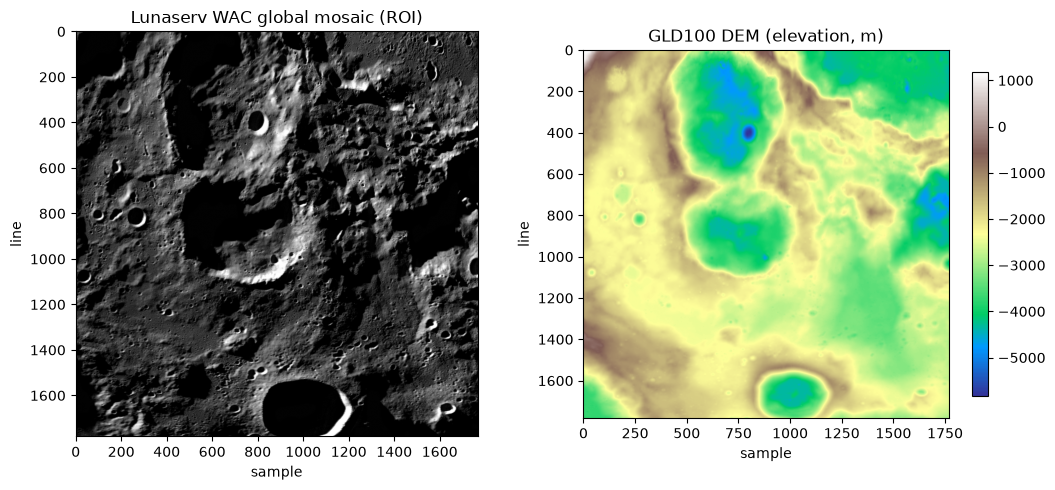

In [5]:
plotting.plot_dem_ortho(lunaserv_result);

### Camera footprint over the DEM

Plot the SPICE-derived camera's ground footprint (corners + center) on top of the ortho mosaic, to visually confirm the pose lands where expected.

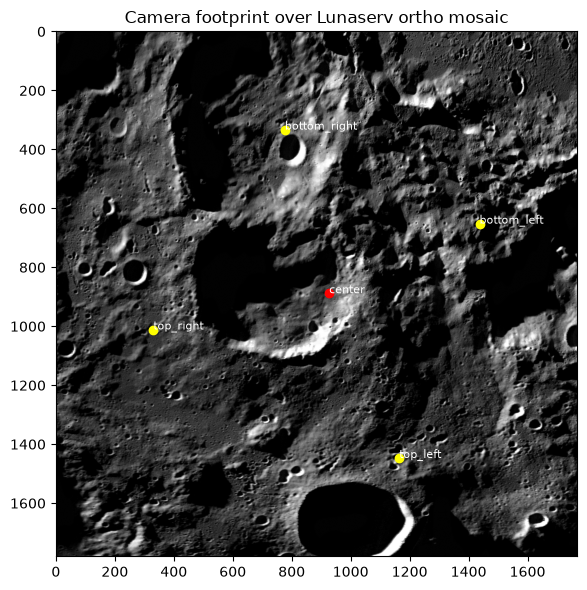

In [6]:
plotting.plot_camera_footprint(lunaserv_result, camera);

## Phase 4: render with `sat_sim` + the real camera pose

`session.run_sat_sim(camera, lunaserv_result)`:
1. Calls `sat_sim --camera-list` with the Phase 2 `.tsai` camera against the Phase 3 DEM/ortho, producing the synthetic 256x256 image.
2. Calls ASP's `cam_gen` to convert that exact camera to a CSM Frame model-state JSON (the "ISD" sidecar) -- `--save-as-csm` is a no-op in `--camera-list` mode, see `docs/data-sources.md`.

	--> Setting number of processing threads to: 4
Writing log: /workspace/output/render/run-log-sat_sim-07-30-1723-377.txt
Reading: /workspace/output/dem_filled-tile-0.tif
Using: nan.
Reading: /workspace/cache/lunaserv/luna_wac_global/96.060143_-84.368864_135.219665_-78.495187_1769x1781.tif
Reading: /workspace/output/camera_list.txt
Generating images.
Writing: /workspace/output/render/run-camera_frame440.tif
        --> [*************************************************************] 0%
Writing: /workspace/output/render/run-images.txt
	--> Setting number of processing threads to: 4
Loading camera model: /workspace/output/render/run-camera_frame440.tif /workspace/output/camera_frame440.tsai
Guessed the datum from camera position.
Using datum: Geodetic Datum --> Name: D_MOON  Spheroid: MOON  Semi-major axis: 1737400  Semi-minor axis: 1737400  Meridian: Reference meridian at 0  Proj4 Str: +proj=longlat +R=1737400 +no_defs
Refining camera intrinsics and pose.
Refine focal length: 0
Refine opt

/opt/venv/lib/python3.13/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


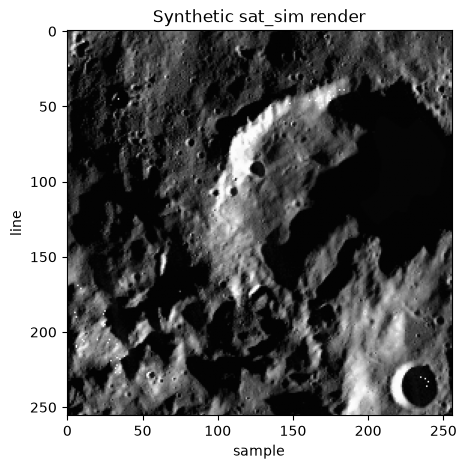

In [7]:
render_result = session.run_sat_sim(camera, lunaserv_result)
plotting.plot_synthetic_render(render_result.rendered_tif);

### The CSM / "ISD" JSON sidecar

The state file's first line is a bare model-name string (not JSON) -- standard CSM "state string" convention; skip it before parsing.

In [8]:
model_name, csm_state = trntest.read_csm_state(render_result.csm_json)

print('Model name:', model_name)
for key in ['m_focalLength', 'm_nLines', 'm_nSamples', 'm_ccdCenter', 'm_currentParameterValue']:
    print(f'{key}: {csm_state[key]}')

Model name: USGS_ASTRO_FRAME_SENSOR_MODEL
m_focalLength: 215.57656937953163
m_nLines: 256
m_nSamples: 256
m_ccdCenter: [128.0, 128.0]
m_currentParameterValue: [-121454.93408189288, 241847.0529709824, -1785989.7606767039, 0.08459214574744284, 0.002452171814241776, 0.44696608507483976, 0.8905388674977123]


`m_currentParameterValue`'s first 3 entries are the camera center (X, Y, Z, meters, MOON_ME frame) and the last 4 are the orientation quaternion -- matching the `C`/`R` we computed from SPICE in Phase 2.

## Phase 5: a recognizable image from the real WAC CDR, with SPICE-derived tie points

WAC is a push-frame camera: each 78-line frame multiplexes 7 filters (2 UV @ 4 TDI lines + 5 VIS @ 14 TDI lines), and per the official LROC SIS, the CDR "will require further processing to separate framelets into their respective bands ... in order to be viewed as a standard image." `session.fetch_vis_mosaic()` does that: it pulls one VIS filter's 14-line block (an offset guaranteed pure-VIS regardless of WAC's current yaw-dependent band ordering -- see the module docstring) from many consecutive frames and stacks them, which is exactly how WAC's push-frame design builds continuous coverage. The frame count is computed (not a fixed guess) so the crop covers the same real ground distance as the synthetic camera's FOV -- see `docs/plan.md`.

This also uncovered why frame 0 never looked like anything: the first ~210 of this product's 538 frames are in near-total shadow (I/F at the noise floor). The target frame index (`config.target_frame_index`) was moved to 440, in a long, stable, well-lit stretch -- and the synthetic camera's pose epoch is the crop's temporal *midpoint* (`camera.center_frame_index`), not its start, so both images are centered on the same ground point.

`session.compute_tie_points()` adds explicit, geometry-derived tie points: it finds the real ground area both images cover (each image's own footprint, an inscribed axis-aligned lon/lat box per image, intersected), picks 5 points in a die's "5"/X pattern (4 corners + center, 10% margin from the shared area's edges), and projects each into both images' pixel coordinates using their real camera models (closed-form pinhole for the synthetic image; a small root-find over frame index for the real crop, which mixes many real poses). Both panels are plotted in real km (not raw pixel index) so the non-square-pixel CDR crop and the square-pixel synthetic image display at the same true scale.

In [9]:
frame_timing = session.fetch_frame_timing()
tie_point_results = session.compute_tie_points(camera, frame_timing)
for name, r in tie_point_results.items():
    print(f"{name:12s} lonlat={r['lonlat']}  synthetic_px={r['synthetic_px']}  crop_px={r['crop_px']}")

top_left     lonlat=(np.float64(111.40551675358536), np.float64(-80.6942704431335))  synthetic_px=(np.float64(228.43732601051863), np.float64(151.18863215475255))  crop_px=(np.float64(627.2823416929523), 587.7474708557129)
top_right    lonlat=(np.float64(121.01787053292105), np.float64(-80.6942704431335))  synthetic_px=(np.float64(97.36375678036912), np.float64(218.47074303557477))  crop_px=(np.float64(268.17400761368054), 849.3386917114258)
center       lonlat=(np.float64(116.2116936432532), np.float64(-81.4151032163698))  synthetic_px=(np.float64(133.28902654599082), np.float64(126.55513773773163))  crop_px=(np.float64(366.55276688828224), 491.3577880859375)
bottom_left  lonlat=(np.float64(111.40551675358536), np.float64(-82.13593598960611))  synthetic_px=(np.float64(156.12320435270186), np.float64(36.25851293793653))  crop_px=(np.float64(430.9298541031448), 133.94186401367188)
bottom_right lonlat=(np.float64(121.01787053292105), np.float64(-82.13593598960611))  synthetic_px=(np.floa

### North-up rotation (display only)

The sensor model's own pixel axes (Part A) are a **fixed, hardware-motivated** choice -- not something that should vary by pass -- but *which way is north* in that fixed convention depends on this specific pass (ascending vs. descending, plus any yaw state), so it's computed here purely for display. `trntest.orientation` picks, for each image independently, the multiple of 90 degrees (no mirroring) whose on-screen "up" is closest to true north, and this is applied only to the plotted arrays and tie-point marker positions below -- the `.tsai`, the CSM/ISD JSON, and `session.compute_tie_points()`'s own returned pixel values are untouched.

Since both images already share the same axis convention (Part A), we expect -- and confirm below -- that they need the *same* rotation here.

In [10]:
rotations = session.compute_display_rotations(camera, frame_timing)
print(f"synthetic: rotate {rotations.k_synthetic*90} deg for north-up (residual {rotations.dev_synthetic_deg:.1f} deg from true north)")
print(f"real crop: rotate {rotations.k_crop*90} deg for north-up (residual {rotations.dev_crop_deg:.1f} deg from true north)")

synthetic: rotate 180 deg for north-up (residual 26.7 deg from true north)
real crop: rotate 180 deg for north-up (residual 26.7 deg from true north)


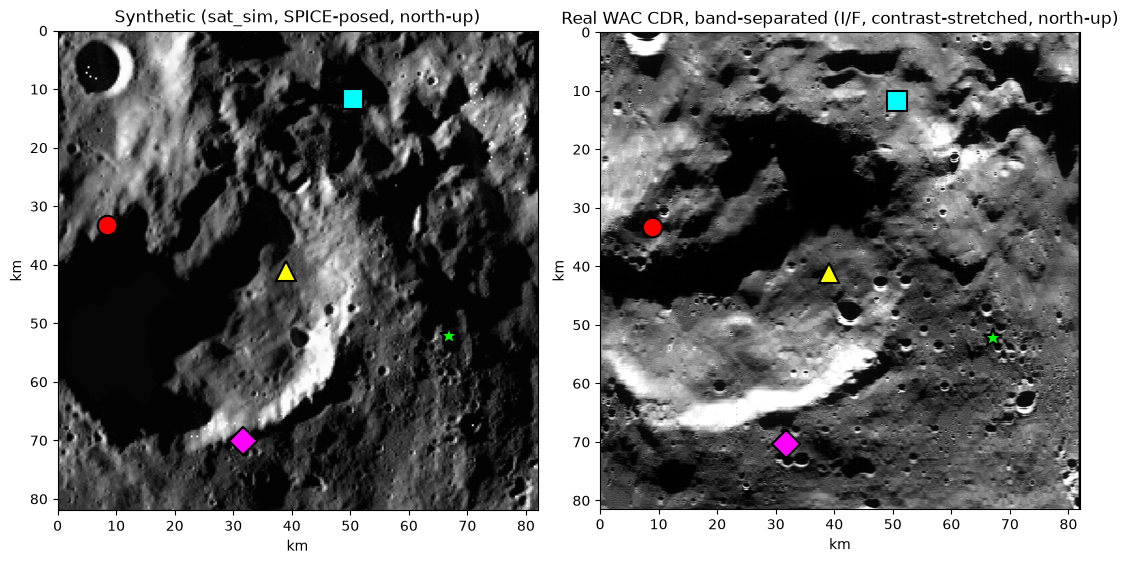

In [11]:
vis_mosaic = session.fetch_vis_mosaic()
plotting.plot_comparison(camera, tie_point_results, vis_mosaic, rotations, render_result.rendered_tif, config=session.config);

## Summary

- Picked a real LROC WAC EDR (`M1329714703CE`), computed LRO's true position/orientation at framelet 440's timestamp directly in the Moon's `MOON_ME` frame via `spiceypy`, using a minimal, selectively-cached SPICE kernel set (see `docs/caching.md`).
- Built a `.tsai` Pinhole camera from that pose and rendered a synthetic 256x256 image with ASP's `sat_sim`, fed by real DEM/imagery pulled live from Lunaserv WMS for the camera's own computed ground footprint.
- Produced a CSM/"ISD" JSON sidecar for the rendered camera (`cam_gen`), and cross-validated the whole pose pipeline: `cam_gen` independently recovered the same sub-spacecraft geodetic position from the `.tsai`'s raw ECEF pose that the original SPICE computation produced.
- Compared against a properly band-separated crop of the real WAC CDR from the same part of the swath -- which required both de-interleaving WAC's push-frame format and discovering (then avoiding) a long shadowed stretch at the start of this particular product.